In [11]:
import matplotlib.pyplot as plt
import numpy as np
from kalman_filter import kalman_filter, extrapolate

## Inference - Parameters (Bisshop 13.75 - 13.83)


Because the model has linear-Gaussian conditional distributions, the transition and emission distributions take the form:

$$p(\mathbf{z}_n | \mathbf{z}_{n-1}) = \mathcal{N}(\mathbf{z}_n | \mathbf{A}\mathbf{z}_{n-1}, \mathbf{\Gamma}) \tag{13.75}$$

$$p(\mathbf{x}_n | \mathbf{z}_n) = \mathcal{N}(\mathbf{x}_n | \mathbf{C}\mathbf{z}_n, \mathbf{\Sigma}) \tag{13.76}$$

The initial latent variable also has a Gaussian distribution:

$$p(\mathbf{z}_1) = \mathcal{N}(\mathbf{z}_1 | \boldsymbol{\mu}_0, \mathbf{V}_0) \tag{13.77}$$

Equivalently expressed as noisy linear equations:

$$\mathbf{z}_n = \mathbf{A}\mathbf{z}_{n-1} + \mathbf{w}_n \tag{13.78}$$

$$\mathbf{x}_n = \mathbf{C}\mathbf{z}_n + \mathbf{v}_n \tag{13.79}$$

$$\mathbf{z}_1 = \boldsymbol{\mu}_0 + \mathbf{u} \tag{13.80}$$

Where the noise terms are distributed as:

$$\mathbf{w} \sim \mathcal{N}(\mathbf{w} | \mathbf{0}, \mathbf{\Gamma}) \tag{13.81}$$

$$\mathbf{v} \sim \mathcal{N}(\mathbf{v} | \mathbf{0}, \mathbf{\Sigma}) \tag{13.82}$$

$$\mathbf{u} \sim \mathcal{N}(\mathbf{u} | \mathbf{0}, \mathbf{V}_0) \tag{13.83}$$

The full parameter set is $\mathbf{\theta} = \{\mathbf{A}, \mathbf{\Gamma}, \mathbf{C}, \mathbf{\Sigma}, \mathbf{\mu}_0, \mathbf{V}_0\}$ , which can be estimated via maximum likelihood using the EM algorithm. The E-step requires solving for the  local posterior marginals over the latent variables, handled efficiently by the sum-product algorithm (Kalman filter + RTS smoother).

## 1D example - Piecewise constant

### System dynamics

In [12]:
a = 3
sigma_obs = 1.0
t_f = 10
domain = (0, t_f)
dt = 0.1
N = int(t_f / dt)
t_test = np.arange(*domain, dt)

t_switch = 0.5*domain[1]
def f(t):
    return (t<t_switch) * a

Z_true = f(t_test).reshape(-1, 1)

In [13]:
t_obs = np.arange(*domain, dt)
X_obs = (f(t_obs) + np.random.normal(0, sigma_obs, N)).reshape(-1, 1)

### Visualize data

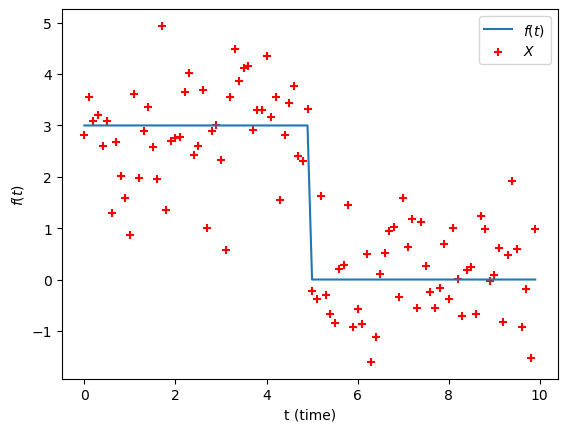

In [14]:
plt.plot(t_test, f(t_test), label="$f(t)$")
plt.scatter(t_obs, X_obs, label="$X$", marker='+', color='red')
plt.legend()
plt.xlabel("t (time)")
plt.ylabel("$f(t)$")
plt.show()

### Inference

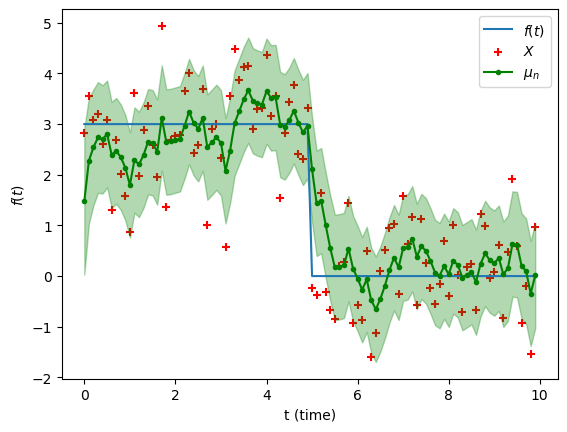

In [15]:
# Model dynamics
A = np.array([[1.0]])
# Measurement dynamics
C = np.array([[1.0]])
# process noise
Gamma = np.eye(1) * 0.1 
# measurement noise
Sigma = np.eye(1) * sigma_obs

mu_0 = np.array([[0.0]])
V_0 = np.array([[1.0]])

mu_hist, V_hist= kalman_filter(X_obs, A, C, Gamma, Sigma, mu_0, V_0)

mu_hist = mu_hist.squeeze()
std = np.sqrt(V_hist).squeeze()

plt.plot(t_test, f(t_test), label="$f(t)$")
plt.scatter(t_obs, X_obs, label="$X$", marker='+', color='red')
plt.plot(t_obs, mu_hist, label="$\mu_n$", marker='.', color='g')
plt.fill_between(t_obs, mu_hist - 2*std, mu_hist + 2*std, alpha=.3, color='g')
plt.legend()
plt.xlabel("t (time)")
plt.ylabel("$f(t)$")
plt.show()

## 2D Case - Position and inferred velocity

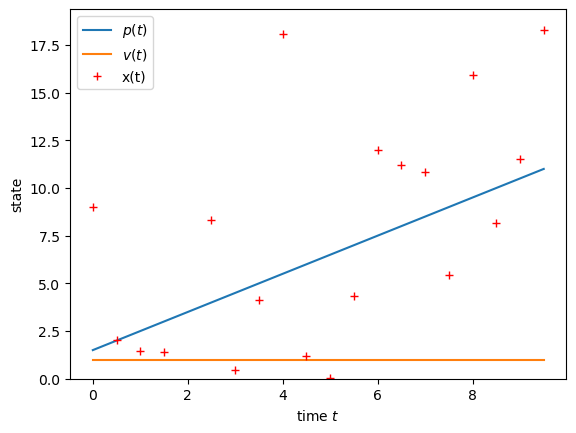

In [16]:
d_z = 2 # latent dim
d_obs = 1 # observation dim
VELOCITY = 1 
z_true_0 = np.array([1, VELOCITY]).reshape(-1, 1) # initial state
sigma_obs = 5
t_f = 10
t_domain = (0, t_f)
dt = .5
N = int(t_f/dt)
t_test = np.arange(*t_domain, dt)

def prop_matrix(dt):
    m = np.array([
        [1, dt],
        [0, 1 ]
    ])
    return m

def f(t, z_0):
    Z_true = np.zeros((t.shape[0], z_0.shape[0]), dtype=np.float32)
    Z_true[0, :] = z_0.squeeze()
    z_t = z_0
    
    for i in range(0, len(t)):
        M = prop_matrix(dt)
        z_t = M @ z_t 
        Z_true[i] = z_t.squeeze()

    return Z_true

Z_true = f(t_test, z_true_0)

t_obs = np.arange(*domain, dt)
X_obs = f(t_obs, z_true_0)[:, 0] + np.random.normal(0, sigma_obs, N)

plt.plot(t_test, Z_true[:, 0], label='$p(t)$')
plt.plot(t_test, Z_true[:, 1], label='$v(t)$')
plt.plot(t_obs, X_obs, label='x(t)', marker='+', ls='', color='r')
plt.ylim(0)
plt.xlabel("time $t$")
plt.ylabel("state")
plt.legend()
plt.show()

### Inference

In [17]:
# Model dynamics
A = np.array([[1.0, dt],
              [0.0, 1.0]])
# Measurement dynamics
C = np.array([[1.0, 0.0]])
# process noise
Gamma = np.array([.01, .01]) @ np.eye(d_z)
# measurement noise
Sigma = np.eye(d_obs) * sigma_obs

mu_0 = np.zeros((d_z, 1))
V_0 = np.eye(d_z)

Text(0, 0.5, '$f(t)$')

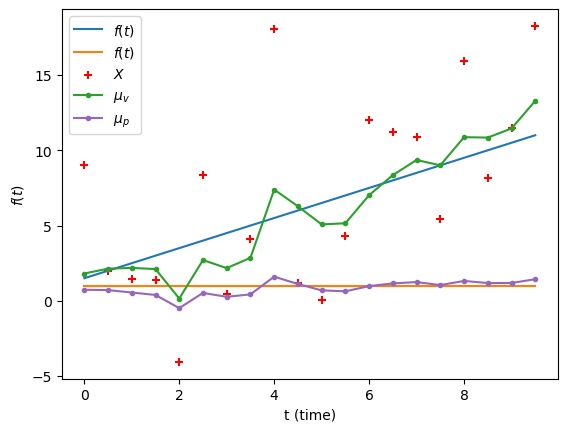

In [18]:
mu_hist, V_hist= kalman_filter(X_obs, A, C, Gamma, Sigma, mu_0, V_0)

mu_hist = mu_hist.squeeze()
std = np.sqrt(V_hist).squeeze()

plt.plot(t_test, f(t_test, z_true_0), label="$f(t)$") 
plt.scatter(t_obs, X_obs, label="$X$", marker='+', color='red')
plt.plot(t_obs, mu_hist.T[0], label="$\mu_v$", marker='.')
plt.plot(t_obs, mu_hist.T[1], label="$\mu_p$", marker='.', color='C4')
plt.legend()
plt.xlabel("t (time)")
plt.ylabel("$f(t)$")
# plt.show()

## The $\Gamma$ / $\Sigma$ Trade-off

The Kalman filter balances two sources of information at every timestep:

- **Dynamics model** $p(\mathbf{z}_n | \mathbf{z}_{n-1}) = \mathcal{N}(\mathbf{z}_n | \mathbf{A}\mathbf{z}_{n-1}, \mathbf{\Gamma})$ — what we *predict* the state will be
- **Observation model** $p(\mathbf{x}_n | \mathbf{z}_n) = \mathcal{N}(\mathbf{x}_n | \mathbf{C}\mathbf{z}_n, \mathbf{\Sigma})$ — what we *measure*

$\mathbf{\Gamma}$ and $\mathbf{\Sigma}$ are **inverse trust** parameters — higher values mean lower trust.

| Parameter | Meaning | Effect when large |
|-----------|---------|-------------------|
| $\mathbf{\Gamma}$ | Process noise — uncertainty in dynamics model | Trust observations more, ignore dynamics |
| $\mathbf{\Sigma}$ | Measurement noise — uncertainty in sensor | Trust dynamics more, ignore observations |

The Kalman gain $\mathbf{K}_n$ encodes this trade-off automatically at each step:

$$\mathbf{K}_n = \mathbf{P}_{n-1}\mathbf{C}^T(\mathbf{C}\mathbf{P}_{n-1}\mathbf{C}^T + \mathbf{\Sigma})^{-1}$$

When $\mathbf{\Sigma}$ is large relative to $\mathbf{P}_{n-1}$, $\mathbf{K}_n \to 0$ — the filter trusts the dynamics prediction and barely moves toward the observation.

When $\mathbf{\Sigma}$ is small relative to $\mathbf{P}_{n-1}$, $\mathbf{K}_n \to 1$ — the filter trusts the observation and largely ignores the dynamics prediction.

### Example: high $\mathbf{\Sigma}$, low $\mathbf{\Gamma}$

If observations are very noisy (`sigma_obs` large) but the dynamics model is accurate (`Gamma` small):

- The filter heavily trusts the dynamics model
- The state estimate barely reacts to individual noisy observations
- The filter propagates forward mostly through $\mathbf{A}$, smoothing aggressively

This works well when the dynamics model is correct (known physics). If the dynamics model is wrong, a small $\mathbf{\Gamma}$ will cause the filter to stubbornly follow the wrong model.

### Practical intuition

> $\mathbf{\Gamma}$ encodes how much you trust your physics.  
> $\mathbf{\Sigma}$ encodes how much you trust your sensors.  
> The filter computes the optimal trade-off between them at every step.


## Extrapolation

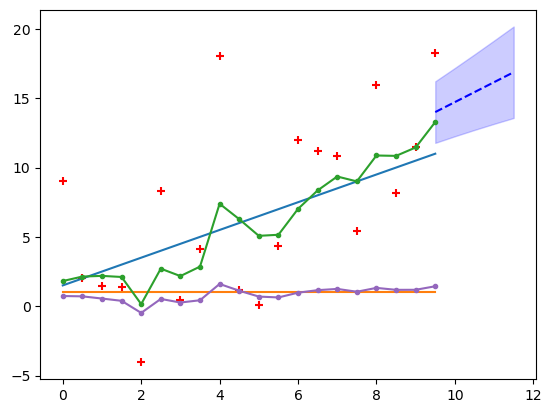

In [19]:
k = 5  # extrapolate 5 steps forward
dt = t_obs[1] - t_obs[0]
t_future = t_obs[-1] + np.arange(0, k) * dt

mu_last = mu_hist[-1].reshape(-1, 1)
V_last  = V_hist[-1]

mu_future, V_future = extrapolate(mu_last, V_last, A, Gamma, k)
mu_future = mu_future.squeeze()
std_future_pos = np.sqrt(V_future[:, 0, 0])


plt.plot(t_test, f(t_test, z_true_0), label="$f(t)$") 
plt.scatter(t_obs, X_obs, label="$X$", marker='+', color='red')
plt.plot(t_obs, mu_hist.T[0], label="$\mu_v$", marker='.')
plt.plot(t_obs, mu_hist.T[1], label="$\mu_p$", marker='.', color='C4')

plt.fill_between(t_future, 
                 mu_future[:, 0] - 2*std_future_pos,
                 mu_future[:, 0] + 2*std_future_pos,
                 alpha=0.2, color='blue', label='extrapolation uncertainty')
plt.plot(t_future, mu_future[:, 0], '--', color='blue', label='extrapolated position')
plt.show()

## 3D case - Acceleration

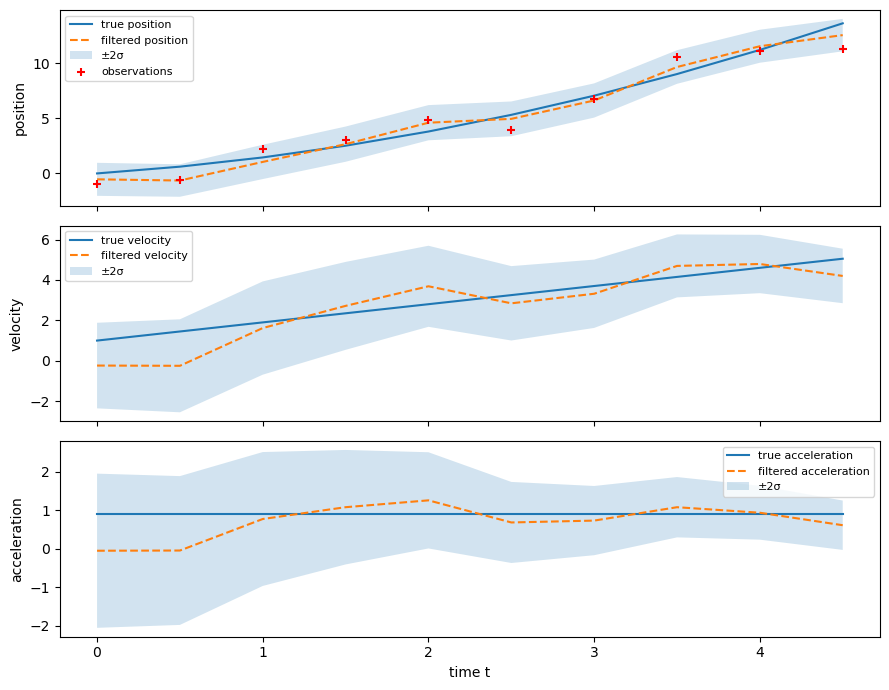

In [20]:
# ── Constant-acceleration model ─────────────────────────────────────────────
# State: z = [position, velocity, acceleration]
# Observation: x = position only

d_z   = 3          # state dimension
d_obs = 1          # observation dimension
N     = 10         # number of observations
dt    = 0.5        # timestep

# True initial state: p=0, v=1, a=0.2
z_true_0 = np.array([[0.0], [1.0], [0.9]])

# State transition matrix  (Taylor expansion of kinematics)
A = np.array([
    [1, dt, 0.5*dt**2],
    [0,  1,        dt],
    [0,  0,         1],
])

# Emission matrix: observe position only
C = np.array([[1.0, 0.0, 0.0]])   # shape (1, 3)

# Noise parameters
Gamma = np.eye(d_z) * 0.01        # small: trust our physics
Sigma = np.array([[1.0]])          # measurement noise

# Initial belief
mu_0 = np.zeros((d_z, 1))
V_0  = np.eye(d_z)

# Generate ground truth and noisy observations
t_obs = np.arange(0, N) * dt

def propagate(t, z_0, A):
    """Propagate initial state z_0 through dynamics A over timesteps t."""
    Z = np.zeros((len(t), z_0.shape[0]))
    Z[0] = z_0.squeeze()
    z = z_0.copy()
    for i in range(1, len(t)):
        z = A @ z
        Z[i] = z.squeeze()
    return Z

Z_true = propagate(t_obs, z_true_0, A)
X_obs  = Z_true[:, 0:1] + np.random.normal(0, Sigma[0,0], (N, 1))

# Run filter
mu_hist, V_hist = kalman_filter(X_obs, A, C,
                                         Gamma, Sigma,
                                         mu_0, V_0)
mu_hist = mu_hist.squeeze()

# Plot: true position vs filtered position, and inferred velocity & acceleration
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

labels = ['position', 'velocity', 'acceleration']
for i, ax in enumerate(axes):
    ax.plot(t_obs, Z_true[:, i],    label=f'true {labels[i]}')
    ax.plot(t_obs, mu_hist[:, i], '--', label=f'filtered {labels[i]}')
    std_i = np.sqrt(V_hist[:, i, i])
    ax.fill_between(t_obs,
                    mu_hist[:, i] - 2*std_i,
                    mu_hist[:, i] + 2*std_i,
                    alpha=0.2, label='±2σ')
    if i == 0:
        ax.scatter(t_obs, X_obs, marker='+', color='red',
                   label='observations', zorder=5)
    ax.legend(fontsize=8)
    ax.set_ylabel(labels[i])

axes[-1].set_xlabel('time t')
plt.tight_layout()
plt.show()